# SCM Dataset Generation — Phase 1-3 Walkthrough

This notebook walks through what the generator actually does, step by step:

1. **Phase 1 (schema)** — build a tiny supply-chain graph by hand and watch the validator catch a bad edge.
2. **Phase 2 (topology generator)** — run the config-driven generator at full scale and inspect what came out: node counts, single- vs multi-source materials, supplier degree concentration, and the attribute dependency functions (not independent random noise) baked into generation.
3. **Phase 3 (normal operations)** — run the discrete-time simulator on top of that graph: demand, production, inventory, and procurement as a time series, and check that production actually tracks demand (a real bug in an earlier version made it collapse to near-zero — see the note in that section).

See `SCM_DATASET_GENERATION_PLAN.md` for the full spec and `DATASET_DESIGN_REVIEW.md` for the design decisions behind these choices.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scm_dataset.schema.nodes import (
    Supplier, Material, Plant, Product, Region, ProcurementOrder, NodeType,
)
from scm_dataset.schema.edges import Edge, EdgeType
from scm_dataset.schema.graph import SupplyChainGraph
from scm_dataset.export.csv import export_graph, load_graph
from scm_dataset.generator.config import load_config
from scm_dataset.generator.topology import generate_graph

plt.rcParams["figure.figsize"] = (7, 4)

## Phase 1: schema — build a tiny graph by hand

Six nodes, one of each type, wired up with all nine edge types.

In [2]:
graph = SupplyChainGraph()

graph.add_node(Region(region_id="R1", country_or_region="Testland", geopolitical_risk=0.2,
                       natural_disaster_risk=0.1, infrastructure_risk=0.1, trade_risk=0.2,
                       cyber_risk=0.1, transport_reliability=0.9))
graph.add_node(Supplier(supplier_id="S1", tier=1, region_id="R1", industry="electronics",
                         capacity=1000.0, capacity_utilization=0.6, reliability=0.9,
                         financial_health=0.8, lead_time_mean=5.0, lead_time_variability=1.0,
                         quality_score=0.95, inventory_buffer=50.0, substitution_availability=0.5,
                         geopolitical_exposure=0.2, disaster_exposure=0.1, cyber_exposure=0.1,
                         criticality=0.7))
graph.add_node(Material(material_id="M1", material_category="chip", criticality=0.8,
                         substitutability=0.3, demand=200.0, unit_cost=10.0, inventory_level=100.0,
                         safety_stock=20.0, supplier_count=1, concentration=1.0,
                         required_quantity_per_product=2.0, procurement_type="MTS"))
graph.add_node(Plant(plant_id="P1", region_id="R1", production_capacity=500.0, utilization=0.7,
                      operating_cost=1000.0, inventory_capacity=200.0, resilience_score=0.6,
                      downtime_cost=5000.0, recovery_rate=0.2))
graph.add_node(Product(product_id="PR1", product_category="widget", demand=300.0,
                        revenue_per_unit=20.0, margin=0.3, material_dependency=0.8,
                        criticality=0.6, substitution_score=0.4, backlog=10.0))
graph.add_node(ProcurementOrder(procurement_id="O1", supplier_id="S1", material_id="M1",
                                 plant_id="P1", order_quantity=50.0, order_value=500.0,
                                 order_frequency=1.0, promised_lead_time=5.0, actual_lead_time=6.0,
                                 urgency=0.3, contract_duration=180.0, priority=0.5))

graph.add_edge(Edge("S1", "M1", EdgeType.SUPPLIER_MATERIAL))
graph.add_edge(Edge("S1", "O1", EdgeType.SUPPLIER_PROCUREMENT))
graph.add_edge(Edge("O1", "M1", EdgeType.PROCUREMENT_MATERIAL))
graph.add_edge(Edge("O1", "P1", EdgeType.PROCUREMENT_PLANT))
graph.add_edge(Edge("M1", "P1", EdgeType.MATERIAL_PLANT))
graph.add_edge(Edge("P1", "PR1", EdgeType.PLANT_PRODUCT))
graph.add_edge(Edge("PR1", "R1", EdgeType.PRODUCT_REGION))
graph.add_edge(Edge("S1", "R1", EdgeType.SUPPLIER_REGION))
graph.add_edge(Edge("P1", "R1", EdgeType.PLANT_REGION))

print(f"{len(graph.nodes)} nodes, {len(graph.edges)} edges")
print("Valid?", graph.is_valid())

6 nodes, 9 edges
Valid? True


### Watch the validator catch a bad edge

`S1` is a `Supplier` and `P1` is a `Plant` — but `SUPPLIER_MATERIAL` edges are only allowed to point `Supplier -> Material`. The validator reports it instead of silently accepting it.

In [3]:
graph.add_edge(Edge("S1", "P1", EdgeType.SUPPLIER_MATERIAL))  # wrong: P1 is a Plant, not a Material
for err in graph.validate():
    print("-", err)

- edge[9] (EdgeType.SUPPLIER_MATERIAL): target_id 'P1' has type NodeType.PLANT, expected NodeType.MATERIAL


## Phase 2: topology generator — full-scale run

Same schema, but now generated end-to-end from `configs/base.yaml` (the plan §8 baseline sizes).

In [4]:
config = load_config(str(repo_root / "configs" / "base.yaml"))
print(config)

big_graph = generate_graph(config)
print(f"{len(big_graph.nodes)} nodes, {len(big_graph.edges)} edges")
print("Valid?", big_graph.is_valid())

GeneratorConfig(seed=42, network=NetworkConfig(suppliers=300, procurement_orders=2000, materials=100, plants=50, products=200, regions=20), topology=TopologyConfig(p_single_source_material=0.3, multi_source_min=2, multi_source_max=5, same_industry_bias=0.8, materials_per_plant_min=5, materials_per_plant_max=20, home_region_bias=0.7), simulation=SimulationConfig(horizon_periods=104, periods_per_year=52, days_per_period=7, demand_seasonal_amplitude=0.3, demand_drift_std=0.05, initial_inventory_periods=4.0, reorder_threshold_periods=1.5, replenishment_multiplier=2.0, supplier_capacity_headroom=1.5))
2670 nodes, 7675 edges
Valid? True


### Node counts by type

procurement    2000
supplier        300
product         200
material        100
plant            50
region           20
dtype: int64

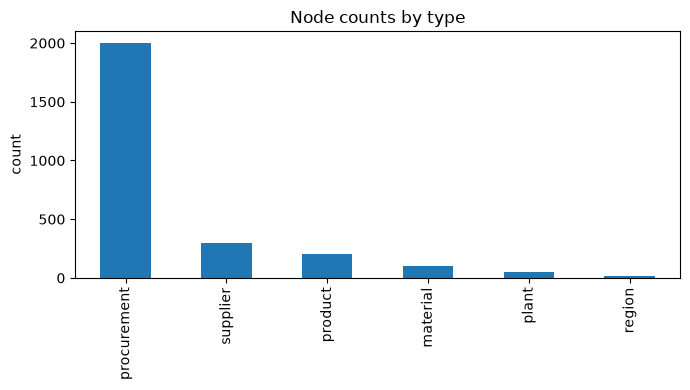

In [5]:
counts = {nt.value: len(big_graph.nodes_of_type(nt)) for nt in NodeType}
counts_series = pd.Series(counts).sort_values(ascending=False)
display(counts_series)

counts_series.plot(kind="bar", title="Node counts by type")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Single-source vs multi-source materials (plan §9)

Materials aren't uniformly given the same number of suppliers — some are deliberately single-sourced (bottlenecks), most have several substitute suppliers.

Single-source materials: 32 / 100


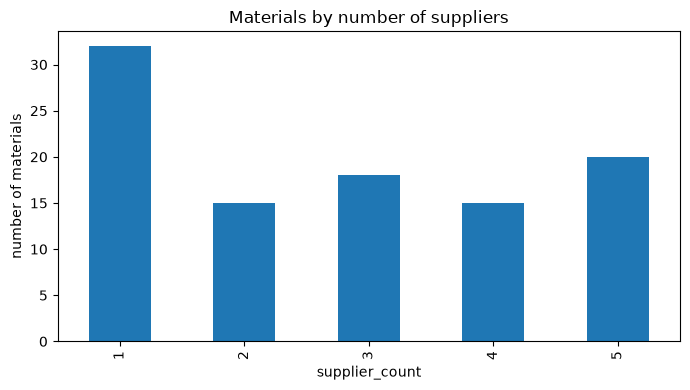

In [6]:
materials = big_graph.nodes_of_type(NodeType.MATERIAL)
supplier_counts = pd.Series([m.supplier_count for m in materials], name="supplier_count")

print(f"Single-source materials: {(supplier_counts == 1).sum()} / {len(supplier_counts)}")

supplier_counts.value_counts().sort_index().plot(kind="bar", title="Materials by number of suppliers")
plt.xlabel("supplier_count")
plt.ylabel("number of materials")
plt.tight_layout()
plt.show()

### Supplier degree concentration — not uniform random edges

Preferential attachment (plan §9) means a handful of suppliers become "critical" — supplying many materials — while most suppliers serve only one or two.

Median supplier out-degree: 1.0, mean: 1.80, max: 6
Top 10 'critical' suppliers by number of materials they supply:


supplier_186    6
supplier_164    5
supplier_210    5
supplier_232    5
supplier_45     5
supplier_265    5
supplier_92     4
supplier_114    4
supplier_16     4
supplier_231    4
dtype: int64

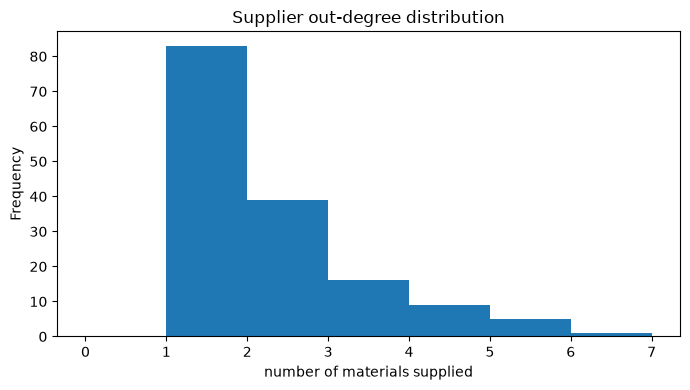

In [7]:
sm_edges = big_graph.edges_of_type(EdgeType.SUPPLIER_MATERIAL)
deg_counter = {}
for e in sm_edges:
    deg_counter[e.source_id] = deg_counter.get(e.source_id, 0) + 1
degrees = pd.Series(deg_counter)

print(f"Median supplier out-degree: {degrees.median()}, mean: {degrees.mean():.2f}, max: {degrees.max()}")
print("Top 10 'critical' suppliers by number of materials they supply:")
display(degrees.sort_values(ascending=False).head(10))

degrees.plot(kind="hist", bins=range(0, int(degrees.max()) + 2), title="Supplier out-degree distribution")
plt.xlabel("number of materials supplied")
plt.tight_layout()
plt.show()

### Attribute dependency functions, not independent noise (plan §13)

Two checks: supplier `reliability` should dip once `capacity_utilization` gets high (less slack to absorb variance), and a supplier's `geopolitical_exposure` should track its region's `geopolitical_risk` rather than being resampled from scratch.

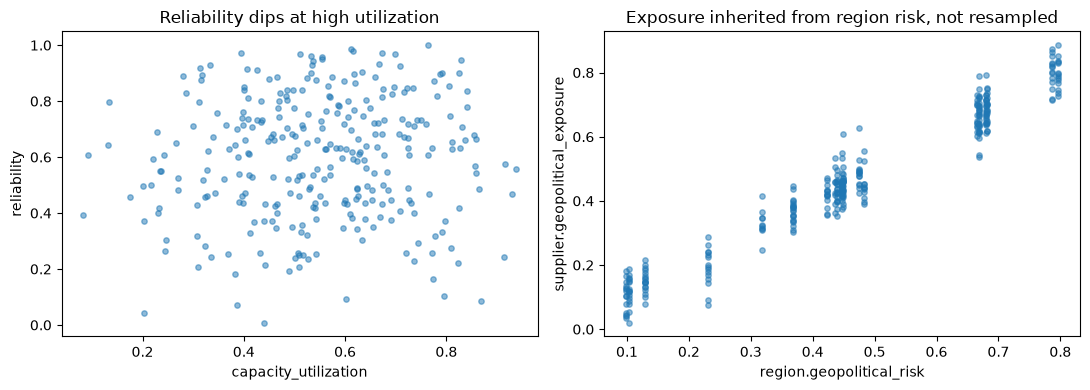

Correlation (region risk vs supplier exposure): 0.976


In [8]:
suppliers = big_graph.nodes_of_type(NodeType.SUPPLIER)
regions_by_id = {r.region_id: r for r in big_graph.nodes_of_type(NodeType.REGION)}

sup_df = pd.DataFrame([{
    "capacity_utilization": s.capacity_utilization,
    "reliability": s.reliability,
    "geopolitical_exposure": s.geopolitical_exposure,
    "region_geo_risk": regions_by_id[s.region_id].geopolitical_risk,
} for s in suppliers])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(sup_df.capacity_utilization, sup_df.reliability, alpha=0.5, s=15)
axes[0].set_xlabel("capacity_utilization")
axes[0].set_ylabel("reliability")
axes[0].set_title("Reliability dips at high utilization")

axes[1].scatter(sup_df.region_geo_risk, sup_df.geopolitical_exposure, alpha=0.5, s=15)
axes[1].set_xlabel("region.geopolitical_risk")
axes[1].set_ylabel("supplier.geopolitical_exposure")
axes[1].set_title("Exposure inherited from region risk, not resampled")
plt.tight_layout()
plt.show()

print("Correlation (region risk vs supplier exposure):",
      round(sup_df.region_geo_risk.corr(sup_df.geopolitical_exposure), 3))

### Validation

In [9]:
errors = big_graph.validate()
print(f"{len(errors)} validation error(s)")

0 validation error(s)


### Export to CSV

Same `graph/nodes.csv` / `graph/edges.csv` / `graph/edge_features.csv` layout the plan (§24) specifies.

In [10]:
output_dir = repo_root / "data" / "generated" / "scm_v1_topology_seed42"
export_graph(big_graph, str(output_dir))

nodes_df = pd.read_csv(output_dir / "graph" / "nodes.csv")
edges_df = pd.read_csv(output_dir / "graph" / "edges.csv")
print(f"Wrote {len(nodes_df)} node rows and {len(edges_df)} edge rows to {output_dir}")
nodes_df.head()

Wrote 2670 node rows and 7675 edge rows to /home/aditya/Desktop/MtechProjectWork/data/generated/scm_v1_topology_seed42


,node_id,node_type,region_id,country_or_region,geopolitical_risk,natural_disaster_risk,infrastructure_risk,trade_risk,cyber_risk,transport_reliability,...,backlog,procurement_id,order_quantity,order_value,order_frequency,promised_lead_time,actual_lead_time,urgency,contract_duration,priority
0,region_0,region,region_0,stable_0,0.098001,0.187523,0.197028,0.052448,0.084891,0.856392,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,region_1,region,region_1,volatile_1,0.668376,0.698320,0.614696,0.787940,0.777779,0.306603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,region_2,region,region_2,moderate_2,0.446751,0.314071,0.436875,0.304112,0.487845,0.595007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,region_3,region,region_3,volatile_3,0.681514,0.631907,0.822254,0.684547,0.657167,0.264787,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,region_4,region,region_4,moderate_4,0.436544,0.441273,0.443082,0.614165,0.359358,0.548776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 3: normal operations — demand, production, inventory, procurement over time

Same `big_graph` from Phase 2. `run_simulation` plays out `config.simulation.horizon_periods` periods (weekly by default) of demand, production, inventory, and procurement, subject to plan §11's constraints (bounded production, no negative inventory, lead-time-gated delivery, capacity-limited suppliers).

In [11]:
from scm_dataset.simulation.engine import run_simulation

result = run_simulation(big_graph, config)
print(f"{len(result.demand_records)} demand rows, {len(result.production_records)} production rows, "
      f"{len(result.inventory_records)} inventory rows, {len(result.deliveries_records)} delivery rows, "
      f"{len(result.procurement_records)} procurement-order rows")

20800 demand rows, 20800 production rows, 67496 inventory rows, 11564 delivery rows, 11764 procurement-order rows


### Demand vs. production for one product

An earlier version of the simulator derived each material's inventory buffer from its own independently-generated `safety_stock`, which turned out to be on a totally different scale than `plant.production_capacity` — production collapsed to near-zero (mean production ~0.44 vs. mean demand ~186 in a full run) because the plant's production is a `min()` over *every* material it needs, and one randomly-undersized material was enough to starve the whole plant. The fix derives every buffer from that (plant, material) pair's own implied consumption rate instead (see `simulation/engine.py`'s docstring). The plot below is the result: production should track demand closely, with the occasional realistic dip while a reorder is in transit.

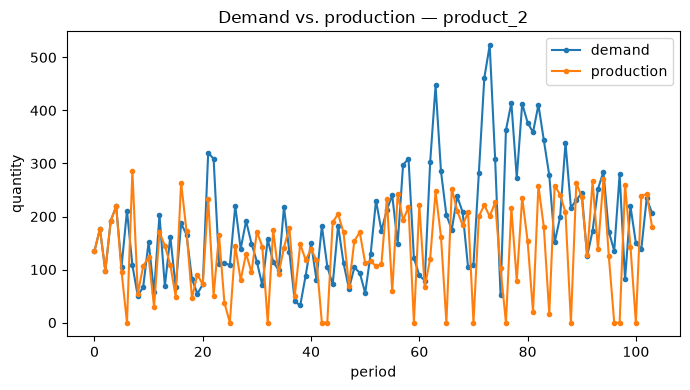

Overall fill rate (total production / total demand) across all products: 0.985


In [12]:
demand_df = pd.DataFrame(result.demand_records)
production_df = pd.DataFrame(result.production_records)
merged = demand_df.merge(production_df, on=["product_id", "time"])

pid = production_df.product_id.iloc[0]
trace = merged[merged.product_id == pid].sort_values("time")

plt.plot(trace.time, trace.demand, label="demand", marker="o", markersize=3)
plt.plot(trace.time, trace.production, label="production", marker="o", markersize=3)
plt.xlabel("period")
plt.ylabel("quantity")
plt.title(f"Demand vs. production — {pid}")
plt.legend()
plt.tight_layout()
plt.show()

fill_rate = merged.production.sum() / merged.demand.sum()
print(f"Overall fill rate (total production / total demand) across all products: {fill_rate:.3f}")

### Inventory trajectory for one (plant, material) pair — the reorder cycle

Inventory should saw-tooth down as the plant consumes it, trigger a reorder once it crosses the reorder threshold, then jump back up when the order arrives after its lead time.

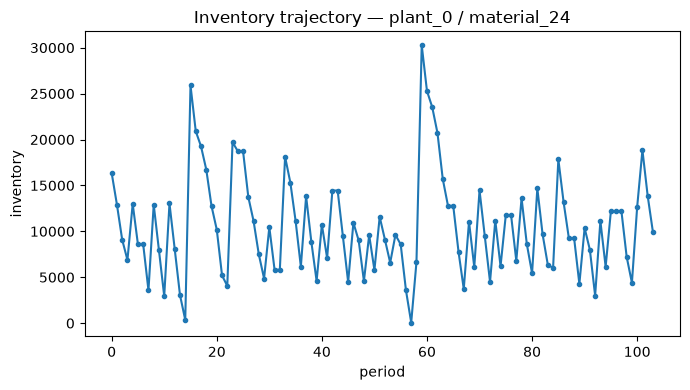

In [13]:
inventory_df = pd.DataFrame(result.inventory_records)
plant_id, material_id = inventory_df.iloc[0][["plant_id", "material_id"]]
trace = inventory_df[(inventory_df.plant_id == plant_id) & (inventory_df.material_id == material_id)].sort_values("time")

plt.plot(trace.time, trace.inventory, marker="o", markersize=3)
plt.xlabel("period")
plt.ylabel("inventory")
plt.title(f"Inventory trajectory — {plant_id} / {material_id}")
plt.tight_layout()
plt.show()

### Export operations tables

Same `operations/*.csv` layout the plan (§24) specifies.

In [14]:
from scm_dataset.export.csv import export_operations

export_operations(result, str(output_dir))
procurement_df = pd.read_csv(output_dir / "operations" / "procurement.csv")
print(f"Wrote operations tables to {output_dir / 'operations'}")
procurement_df.head()

Wrote operations tables to /home/aditya/Desktop/MtechProjectWork/data/generated/scm_v1_topology_seed42/operations


,plant_id,material_id,supplier_id,time_ordered,quantity_ordered,quantity_fulfilled,expected_delivery_time
0,plant_34,material_60,supplier_213,2,6882.878754,6882.878754,6
1,plant_34,material_39,supplier_109,2,2940.508207,2940.508207,3
2,plant_34,material_24,supplier_109,2,9169.497756,9169.497756,3
3,plant_34,material_90,supplier_232,2,2036.491045,2036.491045,4
4,plant_34,material_85,supplier_202,2,4414.390896,4414.390896,3
